In [1]:
import os
os.environ["UNSLOTH_ENABLE_CUSTOM_LOSS"] = "0"
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import os
import json
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import torch

DATA_FILE = "phase1b_sroie_train_reasoning.jsonl" 
BASE_MODEL_DIR = "base_llama3_model"
ADAPTER_DIR = "adapters/SROIE_Adapter"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
print("Initiating SROIE Invoice Agent Training Pipeline...")

if not os.path.exists(BASE_MODEL_DIR):
    raise FileNotFoundError(f"Base model not found at '{BASE_MODEL_DIR}'. Please ensure your offline Llama-3 folder is in the project directory.")

print(f"Loading Base Model OFFLINE from local folder: {BASE_MODEL_DIR}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_DIR,
    max_seq_length = 4096,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16, 
    target_modules = ["q_proj", "v_proj"],
    lora_alpha = 16,
    lora_dropout = 0, 
    bias = "none",    
    use_gradient_checkpointing = True, 
    random_state = 3407,
)

Initiating SROIE Invoice Agent Training Pipeline...
Loading Base Model OFFLINE from local folder: base_llama3_model...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.996 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.2.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [3]:
print("\nLoading and Validating SROIE Data...")
dataset = load_dataset("json", data_files = DATA_FILE, split = "train")

def is_valid_sample(example):
    out = example.get("output")
    if not out or str(out).strip() == "" or out == "TO_BE_GENERATED":
        return False

    if "JSON:" not in str(out):
        return False
    return True

dataset = dataset.filter(is_valid_sample)
print(f"Clean SROIE samples ready for training: {len(dataset)}")


Loading and Validating SROIE Data...
Clean SROIE samples ready for training: 709


In [4]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an intelligent AI invoice extraction agent. Analyze the raw OCR text from the scanned document and extract the key billing entities.
CRITICAL RULES:
1. Extract ONLY these exact four keys: "merchant", "date", "address", and "total". Do NOT add any extra keys like cash or change.
2. Extract the values EXACTLY as they appear in the raw OCR text. Do NOT reformat dates, times, or numbers.
3. ALL values in the JSON must be formatted as strings (e.g., "7.50" instead of 7.50).
4. If a field is missing, output null.

Format your output EXACTLY like this:
Thought: [Explain your reasoning step-by-step]
JSON: 
{{
  "merchant": "...",
  "date": "...",
  "address": "...",
  "total": "..."
}}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token 

In [5]:
def formatting_prompts_func(examples):
    inputs = examples["input"]
    outputs = examples["output"]
    texts = []
    for input_text, output_text in zip(inputs, outputs):
        text = alpaca_prompt.format(input_text, output_text) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts }

dataset = dataset.map(formatting_prompts_func, batched = True)

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"] 

In [6]:
print(f"\nStarting SROIE Training. Saving to {ADAPTER_DIR}...")

os.environ["UNSLOTH_ENABLE_CUSTOM_LOSS"] = "0"

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2, 
    packing = False, 
    
    args = TrainingArguments(
        per_device_train_batch_size = 1, 
        gradient_accumulation_steps = 8, 
        warmup_steps = 5,
        max_steps = 150,  
        learning_rate = 2e-4, 
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(), 
        eval_strategy = "steps",
        eval_steps = 15,
        logging_steps = 5,
        optim = "paged_adamw_8bit", 
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = ADAPTER_DIR,            
        overwrite_output_dir = True, 
    ),
)

trainer.train()


Starting SROIE Training. Saving to adapters/SROIE_Adapter...


Unsloth: Tokenizing ["text"]:   0%|          | 0/638 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/71 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 638 | Num Epochs = 2 | Total steps = 150
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)


Step,Training Loss,Validation Loss
15,2.045600,1.972497
30,1.628000,1.577675
45,1.352100,1.342449
60,1.308400,1.294755
75,1.261800,1.263768
90,1.203700,1.237859
105,1.209600,1.218480
120,1.202200,1.204846
135,1.153300,1.198062
150,1.173200,1.196278


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=150, training_loss=1.3918780104319255, metrics={'train_runtime': 1161.1751, 'train_samples_per_second': 1.033, 'train_steps_per_second': 0.129, 'total_flos': 2.074065305712845e+16, 'train_loss': 1.3918780104319255, 'epoch': 1.877742946708464})

In [7]:
print(f"\nSaving SROIE LoRA Adapter to {ADAPTER_DIR}...")
model.save_pretrained(ADAPTER_DIR) 
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"SROIE Adapter successfully trained and saved!")


Saving SROIE LoRA Adapter to adapters/SROIE_Adapter...
SROIE Adapter successfully trained and saved!


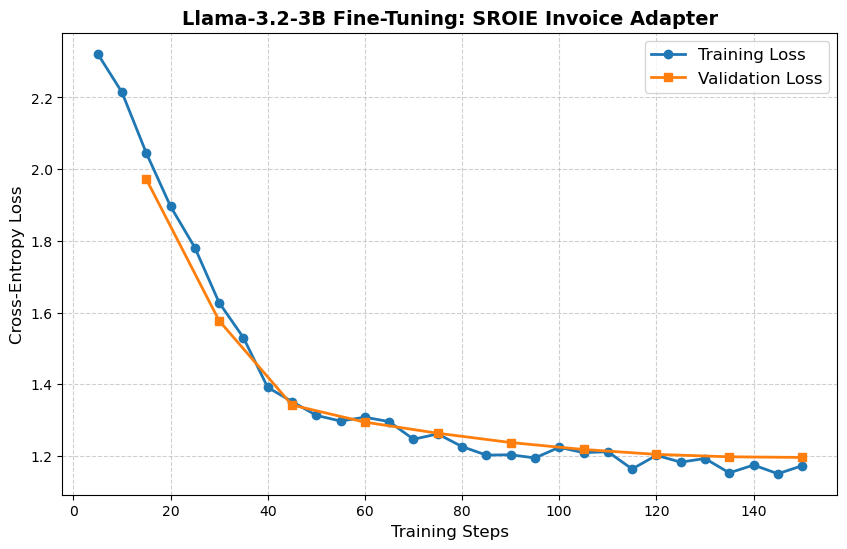

In [8]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    elif "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", marker="o", linewidth=2)

if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="#ff7f0e", marker="s", linewidth=2)

plt.title("Llama-3.2-3B Fine-Tuning: SROIE Invoice Adapter", fontsize=14, fontweight="bold")
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("SROIE_Loss_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# HARD SHUTDOWN & UNLOAD FROM GPU

import torch
import gc

print("Initiating VRAM Hard-Shutdown for Local Models...")

# 1. Track memory before cleanup
if torch.cuda.is_available():
    vram_before = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated Before: {vram_before:.2f} GB")

# 2. List of every heavy object that might be trapped in memory
heavy_objects = [
    'model', 'tokenizer', 'trainer', 'bertscore', 'rouge', 
    'dataset', 'train_dataset', 'eval_dataset', 'split_dataset',
    'inputs', 'outputs'
]

# 3. Delete them dynamically if they exist
for obj in heavy_objects:
    if obj in globals():
        print(f"Unloading '{obj}' from memory...")
        del globals()[obj]

# 4. Force aggressive Garbage Collection (Run twice to clear circular references)
gc.collect()
gc.collect()

# 5. Flush the GPU Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()  # Clears memory shared between backend processes
    torch.cuda.synchronize()  # Waits for all GPU operations to completely finish
    
    # Track memory after cleanup
    vram_after = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated After:  {vram_after:.2f} GB")

print("\nGPU Memory Cleared. Your VRAM is now completely empty!")

Initiating VRAM Hard-Shutdown for Local Models...
VRAM Allocated Before: 2.19 GB
Unloading 'model' from memory...
Unloading 'tokenizer' from memory...
Unloading 'trainer' from memory...
Unloading 'dataset' from memory...
Unloading 'train_dataset' from memory...
Unloading 'eval_dataset' from memory...
Unloading 'split_dataset' from memory...
VRAM Allocated After:  0.75 GB

GPU Memory Cleared. Your VRAM is now completely empty!
